# SKAX 이탈 예측 - 베이스라인 모델링

- **Target**: `is_churn` (1 = 이탈, 0 = 유지)
- **모델**: Logistic Regression / Random Forest / LightGBM 비교
- **데이터**: `features.csv` (멤버십 정보 + 시청 행동 피처)

## 0. 라이브러리

In [ ]:
# 대략적 이거 맞는지는 모르겠음

In [ ]:
%pip install lightgbm xgboost

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import lightgbm as lgb
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

SEED = 42

## 1. 데이터 로드 & 기본 확인

In [20]:
df = pd.read_csv('features.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (17837, 31)


,user_no,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,...,USER_ID,watch_count,unique_movies,active_days,total_duration,avg_duration,avg_completion,days_to_first_watch,cold_start,watch_per_day
0,3dbaf64f285bad12318d0fc90287f109b0300b2651bfb0...,pk_2025,7900.0,151,1.0,N,N,NaN,android,Y,...,13755,5.0,3.0,5.0,310.0,62.000,0.336796,0.0,1,0.161290
1,8153a206cc14eb12ce2a70b726a4ac6702593d623e9452...,pk_1487,100.0,190,1.0,O,N,NaN,mobile,Y,...,6621,2.0,1.0,2.0,81.0,40.500,0.987805,12.0,0,0.064516
2,aee89dd1c5f97e68e379d9ffcff1e5e68aaa5e874b3a75...,pk_1487,7900.0,190,1.0,N,N,O,mobile,Y,...,8216,16.0,11.0,10.0,766.0,47.875,0.279455,2.0,1,0.516129


=== 이탈 분포 ===
is_churn
0    11840
1     5997
Name: count, dtype: int64
이탈률: 33.6%


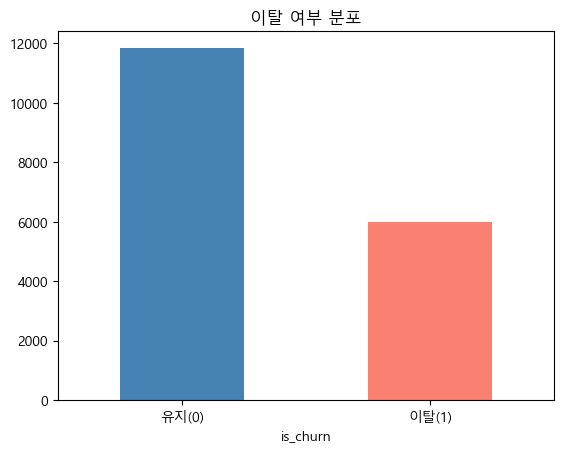

In [21]:
# 타겟 분포 확인
print('=== 이탈 분포 ===')
print(df['is_churn'].value_counts())
print(f'이탈률: {df["is_churn"].mean():.1%}')

df['is_churn'].value_counts().plot(kind='bar', color=['steelblue','salmon'], title='이탈 여부 분포')
plt.xticks([0,1],['유지(0)','이탈(1)'], rotation=0)
plt.show()

In [22]:
# 결측치 확인
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

repurchase            5997
age                    152
concurrent_streams      67
dtype: int64

## 2. 피처 전처리

In [23]:
# 불필요 컬럼 제거 (ID, 날짜, 중복)
# ⚠️ repurchase 제거: 이탈 유저(is_churn=1) 5,997명 전원이 결측 → 타깃과 직결된 데이터 리케이지
drop_cols = ['user_no', 'uid', 'USER_ID', 'reg_date', 'end_date', 'age_group', 'repurchase']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

# is_usd bool -> int
if df_model['is_usd'].dtype == bool or df_model['is_usd'].dtype == object:
    df_model['is_usd'] = df_model['is_usd'].map({'True': 1, 'False': 0, True: 1, False: 0})

# 범주형: LabelEncoder가 NaN 처리 불가 → unknown으로 대체 후 인코딩
cat_cols = ['product_cd', 'billing_method', 'promotion_yn', 'is_churn_prevented',
            'payment_device', 'is_user_verified', 'gender']
cat_cols = [c for c in cat_cols if c in df_model.columns]

le_dict = {}
for c in cat_cols:
    df_model[c] = df_model[c].fillna('unknown')
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c].astype(str))
    le_dict[c] = le

# 수치형: NaN 그대로 유지 (LightGBM / XGBoost 내부 처리)
print('전처리 완료 shape:', df_model.shape)
print('결측치 잔여:\n', df_model.isnull().sum()[df_model.isnull().sum() > 0])
df_model.dtypes.value_counts()

전처리 완료 shape: (17837, 24)
결측치 잔여:
 concurrent_streams     67
age                   152
dtype: int64


float64    12
int32       7
int64       5
Name: count, dtype: int64

## 3. Train / Test Split

In [24]:
X = df_model.drop(columns=['is_churn'])
y = df_model['is_churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train 이탈률: {y_train.mean():.1%} | Test 이탈률: {y_test.mean():.1%}')

Train: (14269, 23), Test: (3568, 23)
Train 이탈률: 33.6% | Test 이탈률: 33.6%


## 4. 모델 학습

### 4-1. LightGBM

In [25]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight: {spw:.2f}')

lgbm = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05,
    num_leaves=63, max_depth=-1,
    scale_pos_weight=spw,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_lgb = lgbm.predict(X_test)
y_prob_lgb = lgbm.predict_proba(X_test)[:, 1]

print('=== LightGBM ===')
print(classification_report(y_test, y_pred_lgb, target_names=['유지','이탈']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}')

scale_pos_weight: 1.97
=== LightGBM ===
              precision    recall  f1-score   support

          유지       0.72      0.90      0.80      2368
          이탈       0.61      0.31      0.41      1200

    accuracy                           0.70      3568
   macro avg       0.66      0.60      0.60      3568
weighted avg       0.68      0.70      0.67      3568

ROC-AUC: 0.6820


### 4-2. XGBoost

In [26]:
xgbm = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, scale_pos_weight=spw,
    tree_method='hist', random_state=SEED,
    n_jobs=-1, verbosity=0,
    early_stopping_rounds=50,
    eval_metric='logloss'
)
xgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb = xgbm.predict(X_test)
y_prob_xgb = xgbm.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb, target_names=['유지','이탈']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

=== XGBoost ===
              precision    recall  f1-score   support

          유지       0.75      0.73      0.74      2368
          이탈       0.50      0.53      0.51      1200

    accuracy                           0.66      3568
   macro avg       0.63      0.63      0.63      3568
weighted avg       0.67      0.66      0.66      3568

ROC-AUC: 0.6793


## 5. 모델 비교

In [27]:
results = pd.DataFrame({
    '모델': ['LightGBM', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lgb),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    'PR-AUC': [
        average_precision_score(y_test, y_prob_lgb),
        average_precision_score(y_test, y_prob_xgb)
    ],
    'F1 (이탈)': [
        f1_score(y_test, y_pred_lgb),
        f1_score(y_test, y_pred_xgb)
    ],
    'Recall (이탈)': [
        recall_score(y_test, y_pred_lgb),
        recall_score(y_test, y_pred_xgb)
    ],
    'Precision (이탈)': [
        precision_score(y_test, y_pred_lgb),
        precision_score(y_test, y_pred_xgb)
    ]
}).set_index('모델').round(4)

results

,ROC-AUC,PR-AUC,F1 (이탈),Recall (이탈),Precision (이탈)
모델,,,,,
LightGBM,0.6820,0.5650,0.4071,0.3058,0.6086
XGBoost,0.6793,0.5646,0.5141,0.5333,0.4961


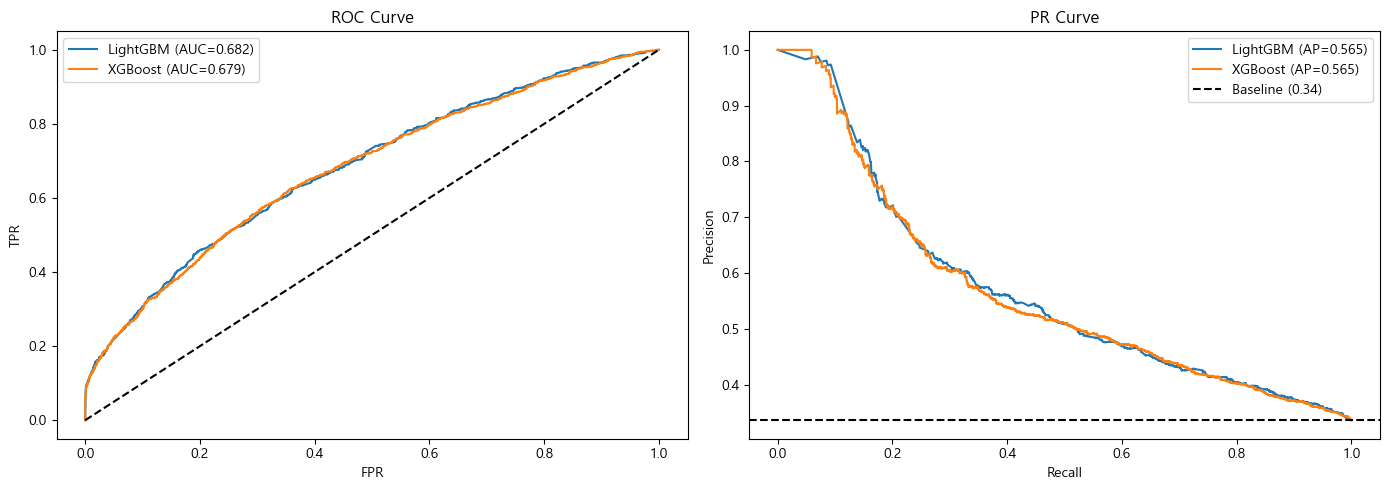

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax = axes[0]
for name, prob in [('LightGBM', y_prob_lgb), ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve'); ax.legend()

# PR Curve
ax = axes[1]
for name, prob in [('LightGBM', y_prob_lgb), ('XGBoost', y_prob_xgb)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')
baseline = y_test.mean()
ax.axhline(baseline, linestyle='--', color='k', label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curve'); ax.legend()

plt.tight_layout()
plt.show()

## 6. 피처 중요도 (LightGBM)

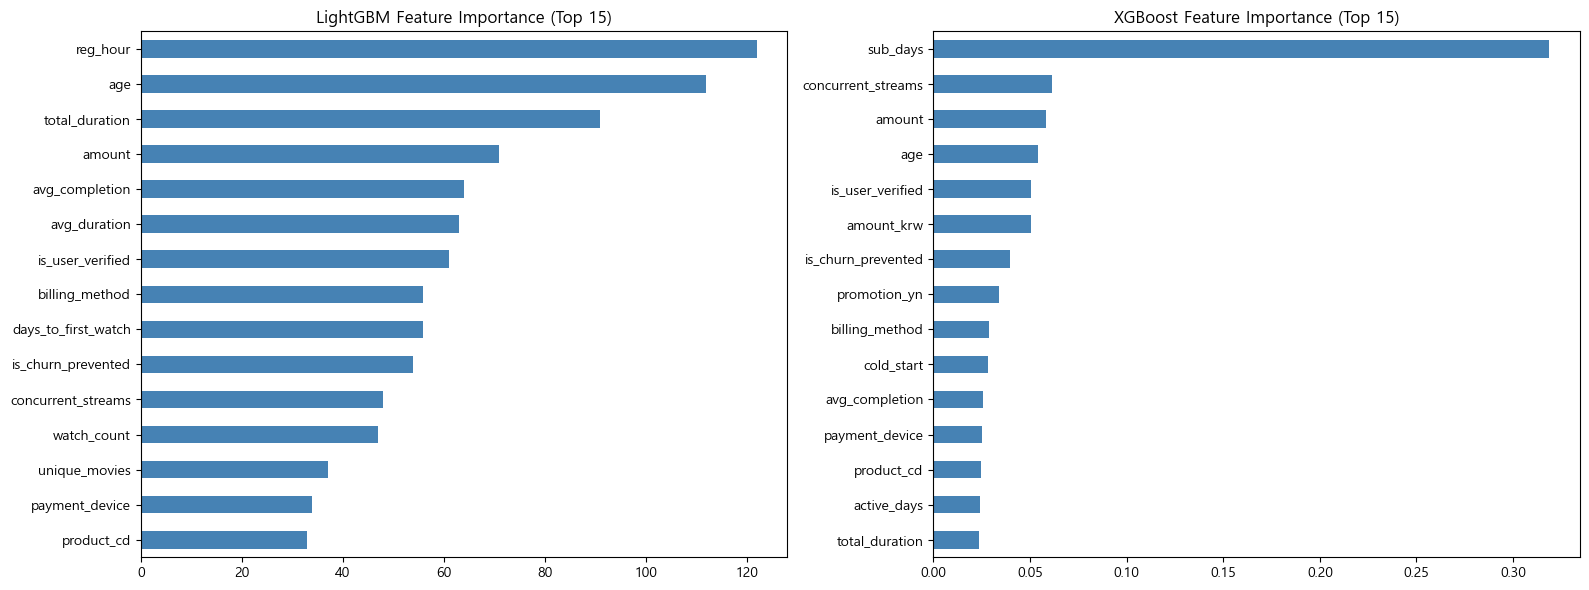

=== LightGBM Top 10 ===
reg_hour               122
age                    112
total_duration          91
amount                  71
avg_completion          64
avg_duration            63
is_user_verified        61
days_to_first_watch     56
billing_method          56
is_churn_prevented      54
dtype: int32


In [29]:
fi_lgb = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
fi_xgb = pd.Series(xgbm.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, fi) in zip(axes, [('LightGBM', fi_lgb), ('XGBoost', fi_xgb)]):
    fi.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

print('=== LightGBM Top 10 ===')
print(fi_lgb.head(10))

## 7. Confusion Matrix (LightGBM)

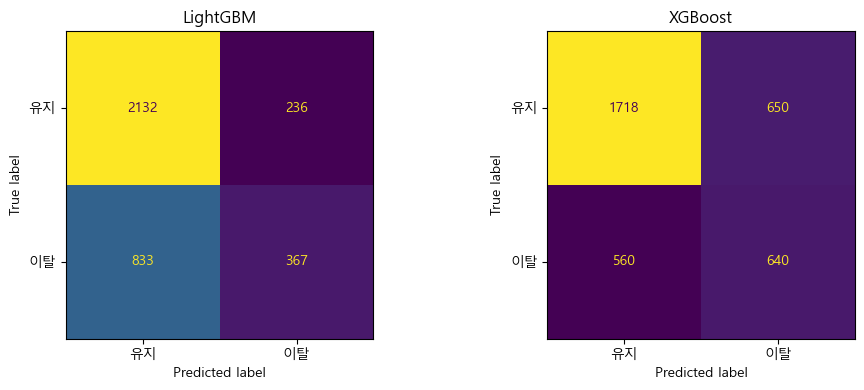

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, pred) in zip(axes, [('LightGBM', y_pred_lgb), ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['유지','이탈'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 8. 요약 & 다음 단계

| 항목 | 내용 |
|------|------|
| 데이터 | features.csv (~17,837행) |
| 타겟 | is_churn (이진 분류, 이탈률 33.6%) |
| 모델 | LightGBM / XGBoost (NaN 자체 처리 가능) |
| age 결측 | 152건 — NaN 그대로 (모델 내부 처리) |

**다음 단계 후보**
- 하이퍼파라미터 튜닝 (Optuna)
- 불균형 처리 (SMOTE, 임계값 조정)
- RF / LR 추가 비교 (age 결측치 처리 후)